# Factory-to-Customer Shipping Route Efficiency Analysis

## Nassau Candy Distributor

### Project Overview

This project analyzes the sales, shipping, cost, profit, and delivery performance of Nassau Candy Distributor.

### Objectives

- Analyze sales performance across regions
- Identify top-performing products
- Analyze shipping modes
- Calculate shipping lead time
- Analyze cost and gross profit
- Calculate regional profit margins
- Generate useful business insights

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## import pandas

In [1]:
import pandas as pd

## Dataset Load

In [2]:
df = pd.read_csv("Nassau Candy Distributor.csv")

## Rows & Columns

In [3]:
print("Rows and Columns:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Rows and Columns: (10194, 18)

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


## Column Names

In [4]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')


## Dataset Information

In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost      

## Missing Values

In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


## Duplicate Rows Check

In [7]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


## Remove Duplicates

In [8]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Rows and Columns after cleaning:",df.shape)

Duplicate rows removed.
Rows and Columns after cleaning: (10194, 18)


## Data Conversion

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed", errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed", errors="coerce")

print("Date columns converted successfully!")
print(df[["Order Date", "Ship Date"]].head())

Date columns converted successfully!
  Order Date  Ship Date
0 2024-03-01 2026-06-30
1 2024-04-01 2026-01-07
2 2024-04-01 2026-01-07
3 2024-04-01 2026-01-07
4 2024-05-01 2026-05-07


## Lead Time Calculation

In [10]:
df["Lead Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
print("Lead Time calculated successfully!")
print(df[["Order Date", "Ship Date", "Lead Time"]].head())

Lead Time calculated successfully!
  Order Date  Ship Date  Lead Time
0 2024-03-01 2026-06-30        851
1 2024-04-01 2026-01-07        646
2 2024-04-01 2026-01-07        646
3 2024-04-01 2026-01-07        646
4 2024-05-01 2026-05-07        736


## Lead Time Basic Analysis

In [11]:
print("Average Lead Time:", df["Lead Time"].mean())
print("Minimum Lead Time:", df["Lead Time"].min())
print("Maximum Lead Time:", df["Lead Time"].max())

Average Lead Time: 1344.2393564842064
Minimum Lead Time: 491
Maximum Lead Time: 1965


## Shipping Mode Lead Time

In [12]:
shipping_mode_analysis = df.groupby("Ship Mode")["Lead Time"].mean()
print("Average Lead Time by Shipping Mode:")
print(shipping_mode_analysis)

Average Lead Time by Shipping Mode:
Ship Mode
First Class       1360.131783
Same Day          1356.488117
Second Class      1352.121273
Standard Class    1336.575980
Name: Lead Time, dtype: float64


## Orders by Shipping Mode

In [13]:
ship_mode_count = df["Ship Mode"].value_counts()

print("Number of Orders by shipping Mode:")
print(ship_mode_count)

Number of Orders by shipping Mode:
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64


## Shipping Mode Orders Graph

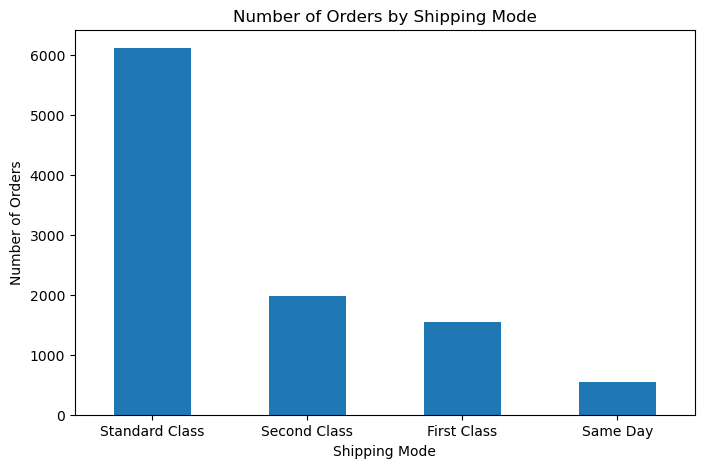

In [14]:
import matplotlib.pyplot as plt

ship_mode_count = df["Ship Mode"].value_counts()
plt.figure(figsize=(8, 5))
ship_mode_count.plot(kind="bar")

plt.title("Number of Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()

## Region-wise Sales

In [15]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("Total Sales by Region:")
print(region_sales)

Total Sales by Region:
Region
Pacific     46301.53
Atlantic    41197.24
Interior    32037.60
Gulf        22247.26
Name: Sales, dtype: float64


## Region-wise Sales Graph

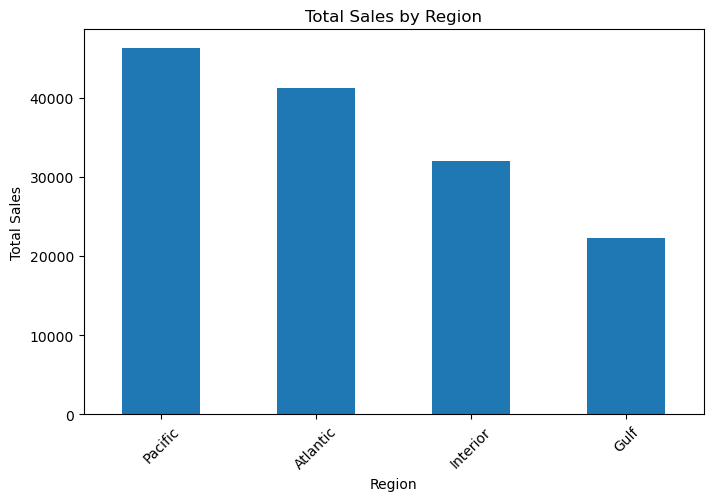

In [16]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

## Top 10 Products

In [17]:
product_sales = (df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False))

print("Top 10 Products by Sales:")
print(product_sales.head(10))

Top 10 Products by Sales:
Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64


## Top 10 Products Graph

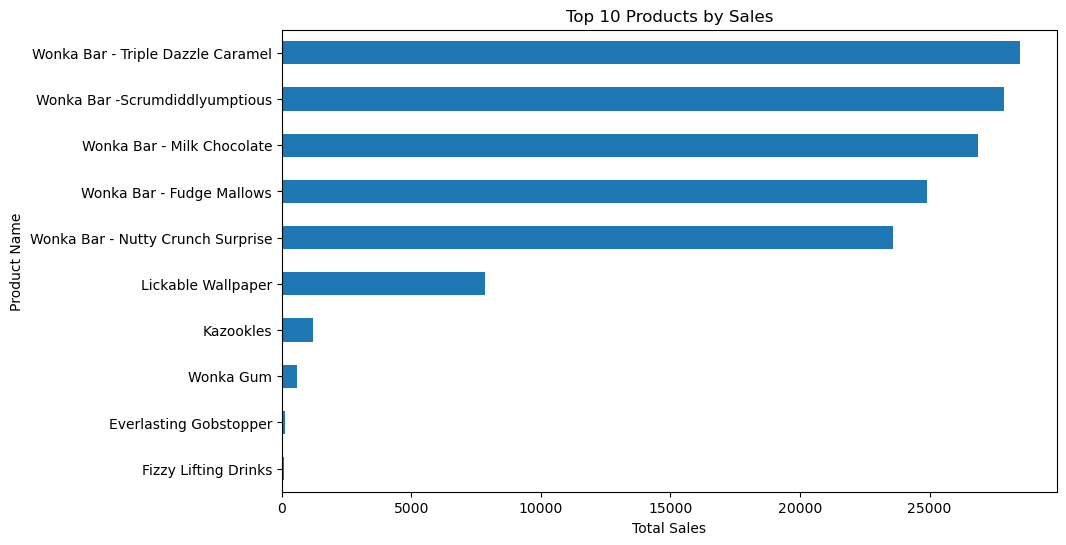

In [18]:
plt.figure(figsize=(10, 6))
product_sales.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

## Orders by Region

In [19]:
region_orders = df["Region"].value_counts()
print("Number of Orders by Region:")
print(region_orders)

Number of Orders by Region:
Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64


## Orders by Region Graph

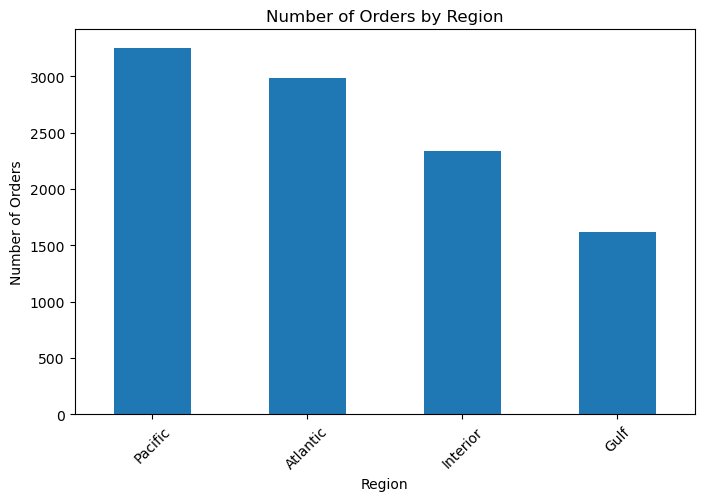

In [20]:
plt.figure(figsize=(8, 5))
region_orders.plot(kind="bar")

plt.title("Number of Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

## Sales Contribution by Region

In [21]:
region_sales_percentage = (df.groupby("Region")["Sales"].sum())
region_sales_percentage = (region_sales_percentage / region_sales_percentage.sum() * 100)

print("Sales Contribution by Region (%):")
print(region_sales_percentage.round(2))

Sales Contribution by Region (%):
Region
Atlantic    29.06
Gulf        15.69
Interior    22.60
Pacific     32.66
Name: Sales, dtype: float64


## Sales Contribution Pie Chart

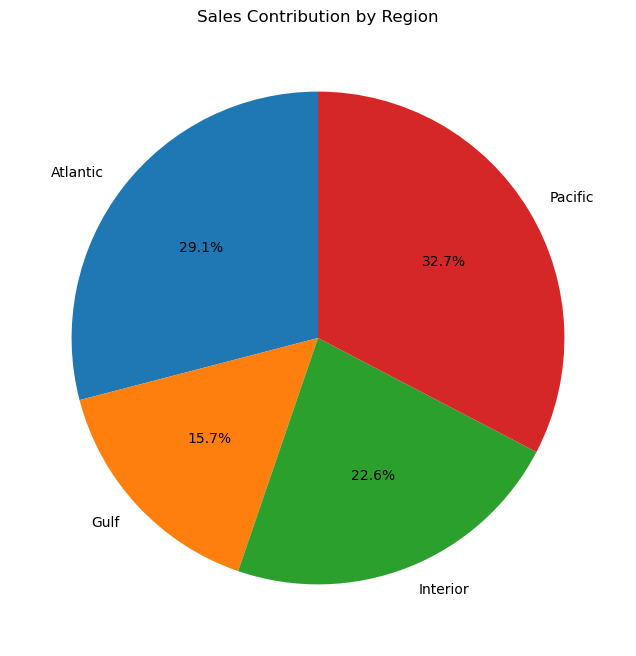

In [22]:
plt.figure(figsize=(8, 8))
plt.pie(region_sales_percentage, labels=region_sales_percentage.index, autopct="%1.1f%%", startangle=90)
plt.title("Sales Contribution by Region")

plt.show()

## Gross Profit by Region

In [23]:
region_profit = (df.groupby("Region")["Gross Profit"].sum().sort_values(ascending=False))
print("Total Gross Profit by Region:")
print(region_profit)

Total Gross Profit by Region:
Region
Pacific     30485.94
Atlantic    26973.70
Interior    21282.49
Gulf        14700.67
Name: Gross Profit, dtype: float64


## Gross Profit Graph

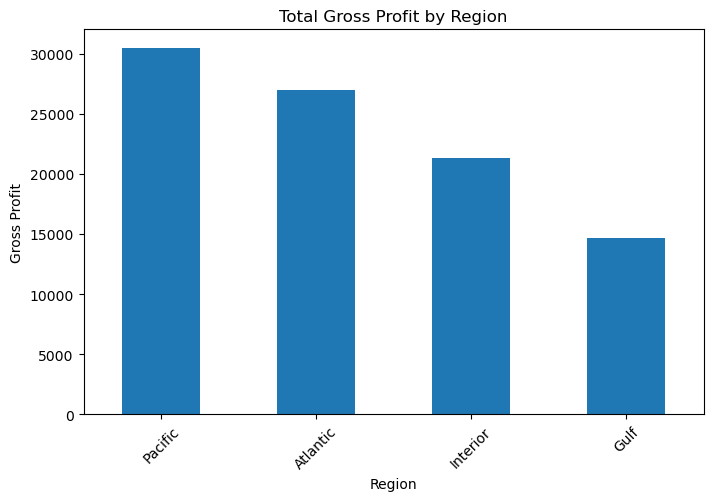

In [24]:
plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar")

plt.title("Total Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)

plt.show()

## Sales by Shipping Mode

In [25]:
ship_mode_sales= (df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False))

print("Total Sales by Shipping Mode:")
print(ship_mode_sales)

Total Sales by Shipping Mode:
Ship Mode
Standard Class    85490.35
Second Class      27860.22
First Class       21319.39
Same Day           7113.67
Name: Sales, dtype: float64


## Shipping Mode Sales Graph

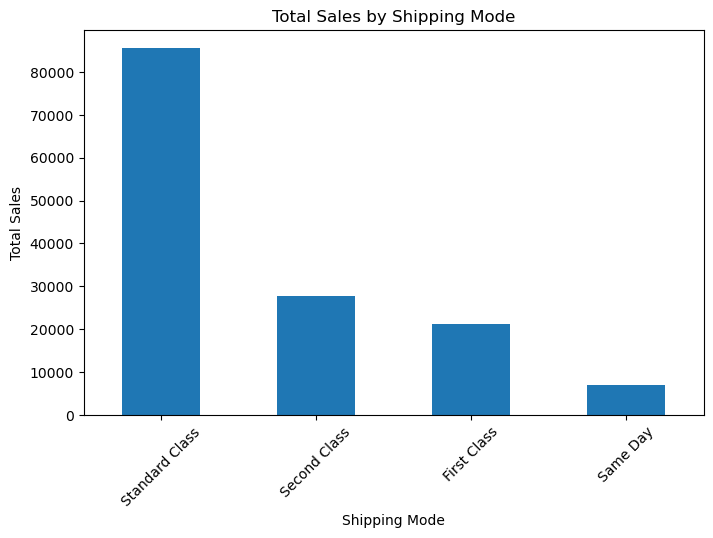

In [26]:
plt.figure(figsize=(8, 5))

ship_mode_sales.plot(kind="bar")

plt.title("Total Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

## Average Lead Time by Shipping Mode

In [27]:
ship_mode_lead_time=( df.groupby("Ship Mode")["Lead Time"].mean().sort_values())
print("Average Lead Time by Shipping Mode:")
print(ship_mode_lead_time.round(2))

Average Lead Time by Shipping Mode:
Ship Mode
Standard Class    1336.58
Second Class      1352.12
Same Day          1356.49
First Class       1360.13
Name: Lead Time, dtype: float64


## Lead Time Graph

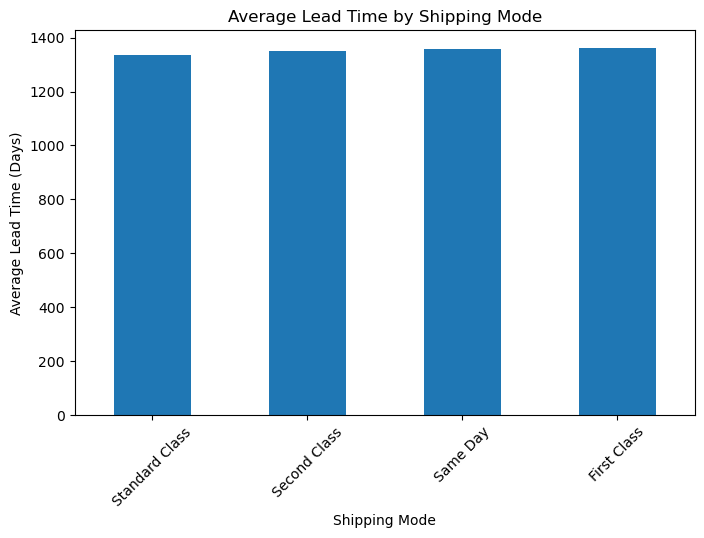

In [28]:
plt.figure(figsize=(8, 5))

ship_mode_lead_time.plot(kind="bar")

plt.title("Average Lead Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)

plt.show()

## Region + Shipping Mode Analysis

In [29]:
region_ship_mode = pd.crosstab(df["Region"], df["Ship Mode"])
print("Orders by Region and Shipping Mode:")
display(region_ship_mode)

Orders by Region and Shipping Mode:


Ship Mode,First Class,Same Day,Second Class,Standard Class
Region,,,,
Atlantic,496,159,548,1783
Gulf,234,83,329,974
Interior,303,120,465,1447
Pacific,515,185,637,1916


## Region + Shipping Mode Graph 

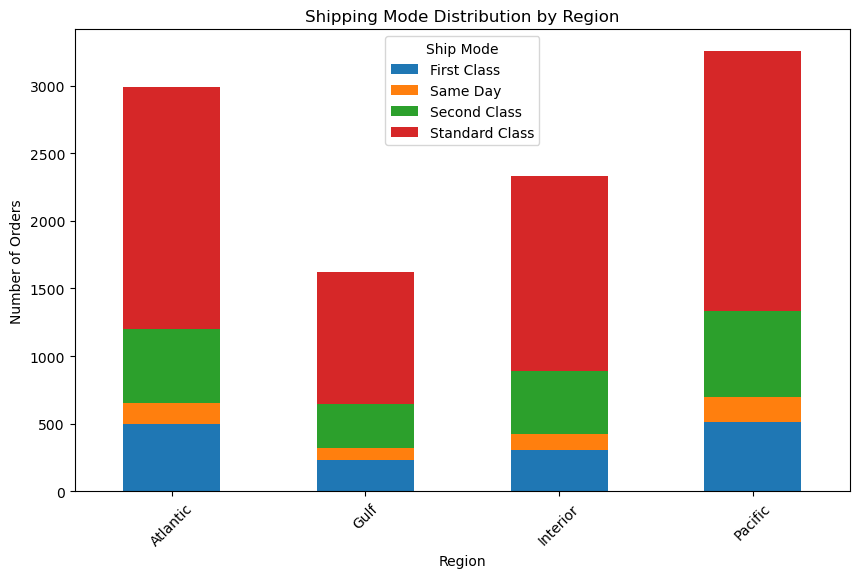

In [31]:
region_ship_mode.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Shipping Mode Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.legend(title="Ship Mode")
plt.show()

## Cost by Region

In [32]:
region_cost = (df.groupby("Region")["Cost"].sum().sort_values(ascending=False))

print("Total Cost by Region:")
print(region_cost)

Total Cost by Region:
Region
Pacific     15815.59
Atlantic    14223.54
Interior    10755.11
Gulf         7546.59
Name: Cost, dtype: float64


## Profit Margin 

In [33]:
region_sales = df.groupby("Region")["Sales"].sum()
region_profit = df.groupby("Region")["Gross Profit"].sum()

profit_margin = (region_profit / region_sales) * 100
print("Profit Margin by Region:")
print(profit_margin.round(2))

Profit Margin by Region:
Region
Atlantic    65.47
Gulf        66.08
Interior    66.43
Pacific     65.84
dtype: float64


## Profit Margin Graph

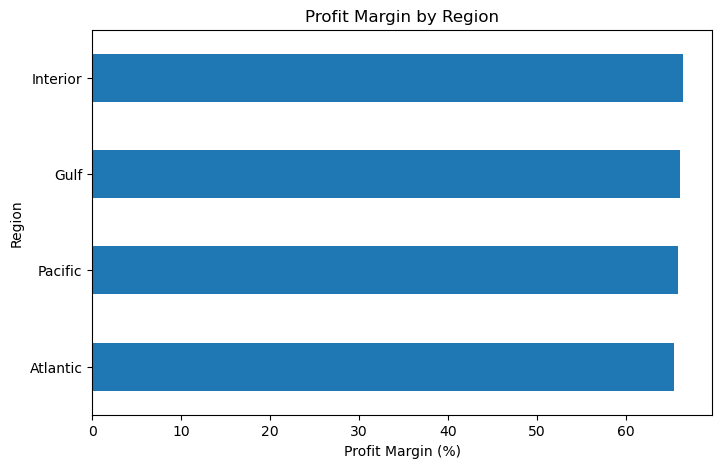

In [34]:
plt.figure(figsize=(8, 5))

profit_margin.sort_values().plot(kind="barh")
plt.title("Profit Margin by Region")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")

plt.show()

## Final KPI Summary

In [35]:
total_orders = len(df)
total_sales = df["Sales"].sum()
total_Cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()
average_lead_time = df["Lead Time"].mean()

print("========FINAL KPI SUMMARY========")
print("Total Orders:", total_orders)
print("Total Sales:", round(total_sales, 2))
print("Total Cost:", round(total_Cost, 2))
print("Total Gross Profit:", round(total_profit, 2))
print("Average Lead Time:", round(average_lead_time, 2), "days")

========FINAL KPI SUMMARY========
Total Orders: 10194
Total Sales: 141783.63
Total Cost: 48340.83
Total Gross Profit: 93442.8
Average Lead Time: 1344.24 days


## Final Insights

In [36]:
best_region_sales = region_sales.idxmax()
best_region_profit = region_profit.idxmax()
best_profit_margin_region = profit_margin.idxmax()
fastest_ship_mode = ship_mode_lead_time.idxmin()
slowest_ship_mode = ship_mode_lead_time.idxmax()

print("========== FINAL INSIGHTS ==========")

print("Highest Sales Region:", best_region_sales)
print("Highest Profit Region:", best_region_profit)
print("Highest Profit Margin Region:", best_profit_margin_region)
print("Fastest Shipping Mode:", fastest_ship_mode)
print("Slowest Shipping Mode:", slowest_ship_mode)

========== FINAL INSIGHTS ==========
Highest Sales Region: Pacific
Highest Profit Region: Pacific
Highest Profit Margin Region: Interior
Fastest Shipping Mode: Standard Class
Slowest Shipping Mode: First Class


## Final Conclusion

In [37]:
print("========== PROJECT CONCLUSION ==========")

print(
    f"The analysis was performed on {total_orders} orders. "
    f"The total sales were {total_sales:.2f}, while the total gross profit was {total_profit:.2f}. "
    f"The average lead time was {average_lead_time:.2f} days."
)

print(
    f"The region with the highest sales was {best_region_sales}, "
    f"while {best_region_profit} generated the highest gross profit."
)

print(
    f"{best_profit_margin_region} had the highest profit margin. "
    f"{fastest_ship_mode} was the fastest shipping mode based on average lead time, "
    f"while {slowest_ship_mode} was the slowest."
)

========== PROJECT CONCLUSION ==========
The analysis was performed on 10194 orders. The total sales were 141783.63, while the total gross profit was 93442.80. The average lead time was 1344.24 days.
The region with the highest sales was Pacific, while Pacific generated the highest gross profit.
Interior had the highest profit margin. Standard Class was the fastest shipping mode based on average lead time, while First Class was the slowest.


# Conclusion

The analysis of the Nassau Candy Distributor dataset provided useful insights into sales, shipping, cost, and profitability.

The project analyzed regional sales, gross profit, product performance, shipping modes, and lead time.

These insights can help the company improve shipping operations, control costs, identify profitable regions, and make better data-driven business decisions.

## Future Scope

The project can be further improved by developing an interactive dashboard using Power BI, Tableau, or Streamlit.